In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import svm
from penex.losses import PENEX
import matplotlib.pyplot as plt
import scienceplots


def generate_data(n_samples, mixture_weigth, mean11, cov11, mean12, cov12, mean2, cov2):
    class1 = np.zeros((n_samples, 2))
    for i in range(n_samples):
        if np.random.rand() < mixture_weigth:
            mean = mean11
            cov = cov11
        else:
            mean = mean12
            cov = cov12
        point = np.random.multivariate_normal(mean, cov, 1)
        class1[i] = point

    class2 = np.random.multivariate_normal(mean2, cov2, n_samples)

    X_np = np.vstack((class1, class2))
    y_np = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

    # Convert to torch tensors
    X = torch.tensor(X_np, dtype=torch.float32)
    y = torch.tensor(y_np, dtype=torch.float32).view(-1, 1)

    return X, y

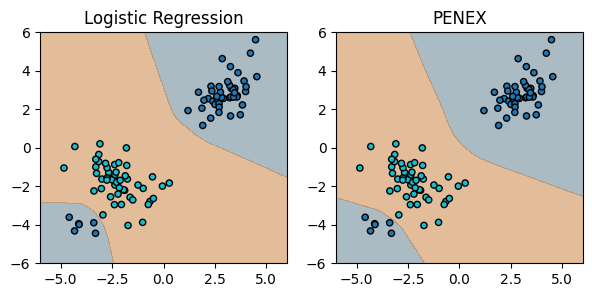

In [37]:
# 1. Generate data from three 2D Gaussians
n_samples_train = 50
n_samples_val = 10000
mean11, cov11 = [3, 3], [[1, 0.5], [0.5, 1]]
mean12, cov12 = [-4, -4], [[0.1, 0], [0, 0.1]]
mixture_weigth = 0.9
mean2, cov2 = [-2, -2], [[1, -0.5], [-0.5, 1]]
num_epochs = 100
eval_steps = 1
alpha = 0.5
SEED = 1
np.random.seed(SEED)
torch.manual_seed(SEED)

X_train, y_train = generate_data(n_samples_train, mixture_weigth, mean11, cov11, mean12, cov12, mean2, cov2)
X_val, y_val = generate_data(n_samples_val, mixture_weigth, mean11, cov11, mean12, cov12, mean2, cov2)
val_criterion = nn.CrossEntropyLoss()

# 2. Define and train logistic regression model in PyTorch
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1 = nn.Linear(2, 50)
        self.linear_2 = nn.Linear(50, 2)

    def forward(self, x, return_logits=False):
        x = torch.relu(self.linear_1(x))
        if return_logits:
            return self.linear_2(x)
        return self.linear_2(x).softmax(dim=1)

logistic_model = LogisticRegression()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(logistic_model.parameters(), lr=0.05)

val_losses_logistic = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = logistic_model(X_train, return_logits=True)
    loss = criterion(outputs, torch.nn.functional.one_hot(y_train.long(), num_classes=2).squeeze().float())
    loss.backward()
    optimizer.step()
    if (epoch + 1) % eval_steps == 0:
        val_outputs = logistic_model(X_val, return_logits=True)
        val_loss = val_criterion(val_outputs, torch.nn.functional.one_hot(y_val.long(), num_classes=2).squeeze().float())
        val_losses_logistic.append(val_loss.item())

# 3. Define and train PENEX model in PyTorch
class PENEXClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1 = nn.Linear(2, 50)
        self.linear_2 = nn.Linear(50, 2)

    def forward(self, x, return_logits=False):
        x = torch.relu(self.linear_1(x))
        if return_logits:
            return self.linear_2(x)
        return self.linear_2(x).softmax(dim=1)

penex_model = PENEXClassifier()
criterion = PENEX(sensitivity=alpha)
optimizer = optim.Adam(penex_model.parameters(), lr=0.05)

val_losses_penex = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = penex_model(X_train, return_logits=True)
    loss = criterion(outputs, torch.nn.functional.one_hot(y_train.long(), num_classes=2).squeeze().float())
    loss.backward()
    optimizer.step()
    if (epoch + 1) % eval_steps == 0:
        val_outputs = penex_model(X_val, return_logits=True)*(1 + alpha)
        val_loss = val_criterion(val_outputs, torch.nn.functional.one_hot(y_val.long(), num_classes=2).squeeze().float())
        val_losses_penex.append(val_loss.item())

# 4. Train SVM model in sklearn
#clf = svm.SVC(kernel='linear', C=1e12)
#clf.fit(X_np, y_np)

# 4. Plot decision boundaries
xx, yy = np.meshgrid(np.linspace(-6, 6, 200), np.linspace(-6, 6, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predictions for PyTorch logistic regression
with torch.no_grad():
    logistic_pred = logistic_model(torch.tensor(grid, dtype=torch.float32))[:, 1].numpy().reshape(xx.shape)

# Predictions for sklearn SVM
#svm_scores = clf.decision_function(grid).reshape(xx.shape)

# Predictions for PyTorch PENEX
with torch.no_grad():
    penex_logits = penex_model(torch.tensor(grid, dtype=torch.float32), return_logits=True) * (1 + alpha)
    penex_pred = penex_logits.softmax(dim=1)[:, 1].numpy().reshape(xx.shape)

plt.figure(figsize=(7, 3))

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib

# plt.style.use(["science", "vibrant"])
# #plt.rcParams['font.family'] = 'serif'
# #plt.rcParams['font.serif'] = ['Computer Modern Roman']
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['text.latex.preamble'] = r'\usepackage[utopia]{mathdesign}'
# plt.rcParams['legend.frameon'] = True
# plt.rcParams['legend.fancybox'] = True
# # retrieve the color cycle from the style
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
cmap = ListedColormap(color_cycle)

# create a custom colormap
transition = LinearSegmentedColormap.from_list("transition", [color_cycle[0], color_cycle[1]])

# Logistic Regression
plt.subplot(1, 2, 1)
plt.contourf(
    xx, 
    yy, 
    logistic_pred, 
    levels=[0, 0.5, 1],  # more levels for smoother gradient
    cmap=transition, 
    alpha=0.5
)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap, edgecolors='k', s=20)
plt.title("Logistic Regression")

# SVM
# plt.subplot(1, 3, 2)
#plt.contourf(xx, yy, svm_scores > 0, levels=[0, 0.5, 1],
#             alpha=0.2, colors=['blue', 'red'])
#plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap=plt.cm.bwr, edgecolors='k')
#plt.title("Hard-margin SVM (C -> ∞)")

# PENEX
plt.subplot(1, 2, 2)
# Use it in contourf
plt.contourf(
    xx, 
    yy, 
    penex_pred, 
    levels=[0, 0.5, 1],  # more levels for smoother gradient
    cmap=transition, 
    alpha=0.5
)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap, edgecolors='k', s=20)
plt.title("PENEX")

plt.show()

#plt.savefig("plots/logistic_vs_penex.pdf", bbox_inches='tight', dpi=300)

In [38]:
def multiclass_geometric_margin(model, X, y):
    """
    Approximates the geometric margin (distance to decision boundary) for each sample.
    model: PyTorch model, returns logits (N, C) when called with return_logits=True
    X:     torch.Tensor, shape (N, D) input data (requires_grad will be set)
    y:     torch.Tensor or np.ndarray, shape (N,) integer class labels in [0, C-1]
    Returns: np.ndarray of geometric margins, shape (N,)
    """
    model.eval()
    X = X.clone().detach().requires_grad_(True)
    logits = model(X, return_logits=True)
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else y
    N, C = logits.shape
    margins = np.zeros(N)
    for i in range(N):
        yi = y_np[i]
        # Find impostor class (highest logit not equal to yi)
        logit_row = logits[i]
        impostor_idx = (torch.arange(C) != yi).nonzero(as_tuple=True)[0]
        impostor_scores = logit_row[impostor_idx]
        k_star = impostor_idx[impostor_scores.argmax()].item()
        # Score difference
        diff = logits[i, yi] - logits[i, k_star]
        # Compute gradient of diff w.r.t. input
        model.zero_grad()
        if X.grad is not None:
            X.grad.zero_()
        diff.backward(retain_graph=True)
        grad = X.grad[i].detach().cpu().numpy()
        grad_norm = np.linalg.norm(grad) + 1e-12  # avoid division by zero
        margins[i] = diff.item() / grad_norm
    return margins

In [39]:
# PENEX wrapper
class PENEXWrapper(nn.Module):
    def __init__(self, model, alpha):
        super().__init__()
        self.model = model
        self.alpha = alpha

    def forward(self, x, return_logits=False):
        if return_logits:
            return self.model(x, return_logits=True) * (1 + self.alpha)
        else:
            return (self.model(x, return_logits=True) * (1 + self.alpha)).softmax(dim=1)

penex_model_wrapper = PENEXWrapper(penex_model, alpha)
# Compute margins for PyTorch PENEX
margins_penex = multiclass_geometric_margin(penex_model_wrapper, X_train, np.array(y_train).astype(int).squeeze())

/tmp/ipykernel_2924212/3954942547.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  margins_penex = multiclass_geometric_margin(penex_model_wrapper, X_train, np.array(y_train).astype(int).squeeze())


In [40]:
margins_logistic = multiclass_geometric_margin(logistic_model, X_train, np.array(y_train).astype(int).squeeze())

/tmp/ipykernel_2924212/1010593881.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  margins_logistic = multiclass_geometric_margin(logistic_model, X_train, np.array(y_train).astype(int).squeeze())


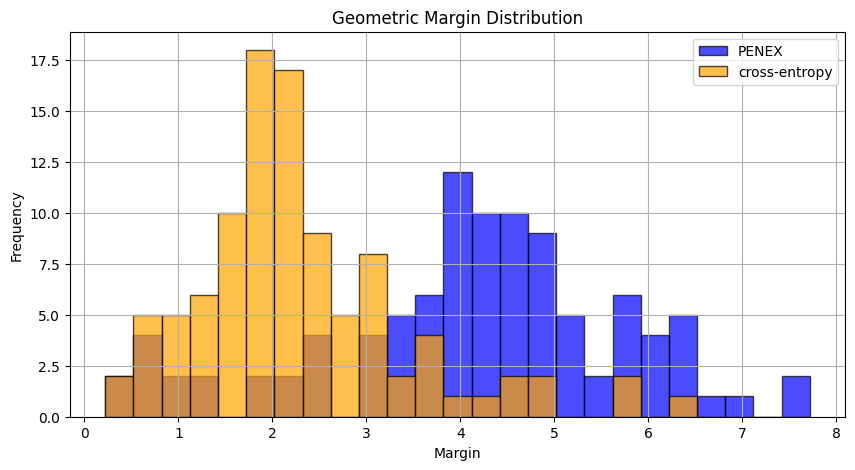

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

all_margins = np.concatenate([margins_penex, margins_logistic])
bin_width = 0.3  # Set your desired bin width here
bins = np.arange(all_margins.min(), all_margins.max() + bin_width, bin_width)

plt.hist(margins_penex, bins=bins, alpha=0.7, color='blue', edgecolor='black')
plt.hist(margins_logistic, bins=bins, alpha=0.7, color='orange', edgecolor='black')
plt.legend(['PENEX', 'cross-entropy'])
plt.title('Geometric Margin Distribution')
plt.xlabel('Margin')
plt.ylabel('Frequency')
plt.grid()
plt.show()

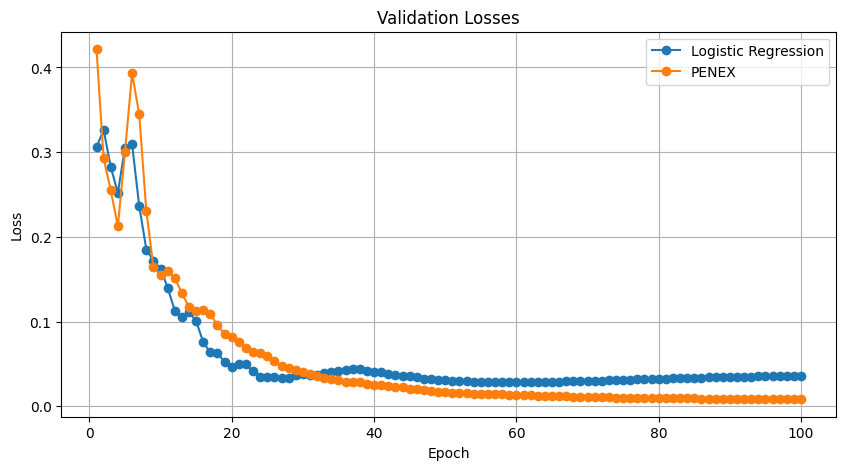

In [42]:
# Plot validation losses
plt.figure(figsize=(10, 5))
plt.plot(range(eval_steps, num_epochs + 1, eval_steps), val_losses_logistic, label='Logistic Regression', marker='o')
plt.plot(range(eval_steps, num_epochs + 1, eval_steps), val_losses_penex, label='PENEX', marker='o')
plt.title('Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()